## Problem Statement 

A company offers personal loan and home loans to coustomers.
Until now company has been using a manula verification process which result in -
    Good coustomes somtimes get rejected
    High rish customers sometimes get approved

I am hired as a machine learning Engineer to disign and develop this sitelligent system using historical load apploication data.



In [226]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score , f1_score  , recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [227]:
data = pd.read_csv("loan_approval_data.csv")
data

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [228]:
data.describe()
data.duplicated()
data.isnull().sum()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

## 1. Data Cleaning

    -- Handling Missing Values: Dropping rows or filling them (imputation).
    -- Removing Duplicates: Ensuring no redundant data.
    -- Correcting Data Types: Making sure "Age" is an integer, not text.
    -- Handling Outliers: Deciding whether to keep or remove those dots we discussed in your boxplots.

In [229]:
Categorical_col = data.select_dtypes(include = ["object"]).columns
Numerical_col =  data.select_dtypes(include = ["number"]).columns

In [230]:
Numerical_imputer = SimpleImputer(strategy="mean")
Categorical_imputer = SimpleImputer(strategy = "most_frequent")
data[Numerical_col ] = Numerical_imputer.fit_transform(data[Numerical_col])
data[Categorical_col] = Categorical_imputer.fit_transform(data[Categorical_col])

In [231]:

data = data.drop("Applicant_ID" , axis = 1 )

## 2. Exploratotry data Analysis

([<matplotlib.patches.Wedge at 0x213b5f27390>,
 [Text(-0.40814808922615514, 1.0214769391724117, 'No'),
  Text(0.4081485438350891, -1.0214767575257386, 'Yes')],
 [Text(-0.22262623048699368, 0.5571692395485881, '62.1%'),
  Text(0.22262647845550312, -0.5571691404685846, '37.9%')])

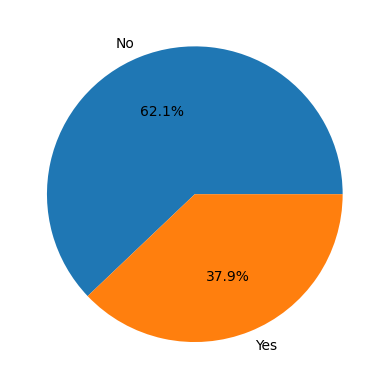

In [232]:
# By doing this we analys the relation between diffrent parameters which will help us in feature enginearing

gender_count = data["Gender"].value_counts()
plt.pie(gender_count , labels = ["No" , "Yes"] , autopct = "%1.1f%%")

([<matplotlib.patches.Wedge at 0x213bc8fae90>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

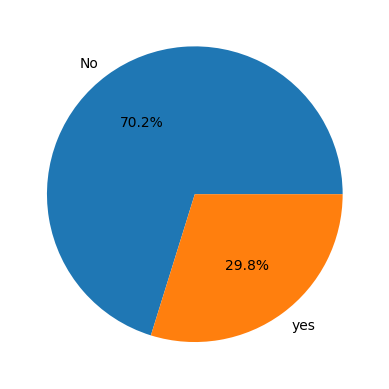

In [233]:
approval = data["Loan_Approved"].value_counts()
plt.pie(approval , labels = ["No" , "yes"] , autopct = "%1.1f%%" )

<Axes: xlabel='Applicant_Income', ylabel='Count'>

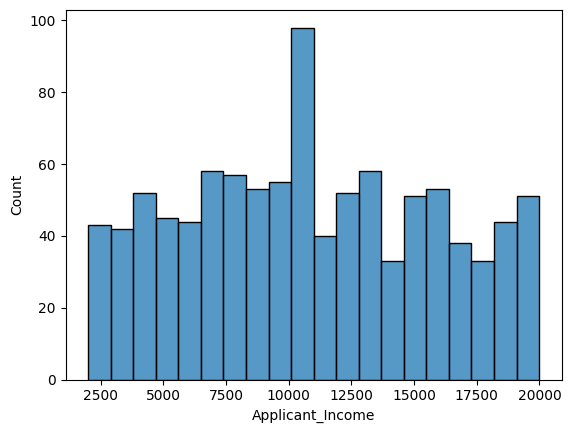

In [234]:
sns.histplot ( data , x = "Applicant_Income" , bins = 20 )


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


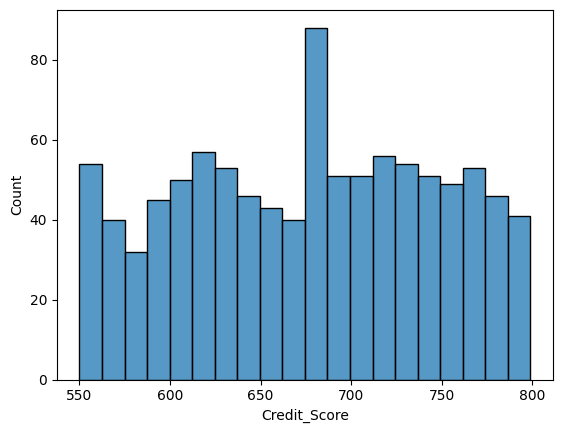

In [235]:
sns.histplot(data , x = "Credit_Score" , bins = 20 )
data

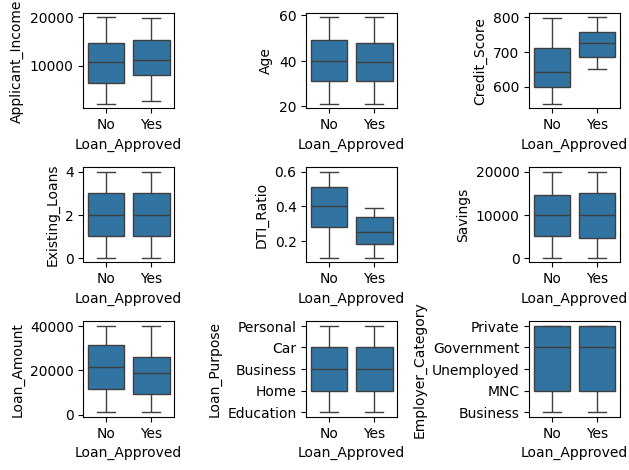

In [236]:
# creating box plot to check if their exist an outlier in the data in any of the categorical data

fig , axes = plt.subplots(3 ,3)

sns.boxplot(ax = axes[0,0] , data = data , x = "Loan_Approved" , y = "Applicant_Income")
sns.boxplot(ax = axes[0,1] , data = data , x = "Loan_Approved" , y = "Age")
sns.boxplot(ax = axes[0,2] , data = data, x = "Loan_Approved" , y = "Credit_Score")
sns.boxplot(ax = axes[1,0] , data = data , x = "Loan_Approved" , y = "Existing_Loans")
sns.boxplot(ax = axes[1,1] , data= data  , x = "Loan_Approved" , y = "DTI_Ratio")
sns.boxplot(ax = axes[1,2] , data = data, x = "Loan_Approved" , y = "Savings")
sns.boxplot(ax = axes[2,0] , data = data, x = "Loan_Approved" , y = "Loan_Amount")
sns.boxplot(ax = axes[2,1] , data = data, x = "Loan_Approved" , y = "Loan_Purpose")
sns.boxplot(ax = axes[2,2] , data = data, x = "Loan_Approved" , y = "Employer_Category")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

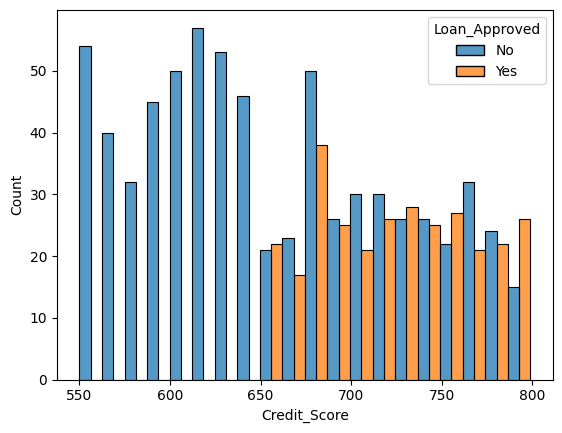

In [237]:
sns.histplot(
    data = data,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20 ,
    multiple = "dodge"
)

## 3. Data Preprocessing

    -- Feature Encoding: Converting text (like "Yes"/"No" or "Manager") into numbers 
    -- Feature Scaling: Normalizing or Standardizing numbers so "Income" (thousands) doesn't overrule "Age" (tens)just because the number is bigger.
    -- Feature Selection: Picking the most important columns to train on.

In [238]:
# Feature Encoding 

# 1. Binary encoding where we use map means - yes = 1 , no = 0 - for this we also use - labelEncoder
# 2. OneHotEncoding - for this - apart from get_dummies we also use - OneHotEncoder these both are sklearn libraries

le = LabelEncoder()
data["Education_Level"] = le.fit_transform(data["Education_Level"])  
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])

ohe = OneHotEncoder(drop = "first" , sparse_output=False , handle_unknown='ignore')

cols = ["Marital_Status", "Gender","Employer_Category","Property_Area","Loan_Purpose","Employment_Status"]

encoded = ohe.fit_transform(data[cols])

# encode is a 2D array we have to convert it to dataframe
Encoded_data = pd.DataFrame(encoded , columns = ohe. get_feature_names_out(cols) , index = data.index)

# Now we have to concatinate the Encoded data to the actual data
data = pd.concat([data.drop(columns = cols) , Encoded_data] , axis = 1)


In [239]:
data.head()


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Correlation heatmap

In [240]:
numerical_cols = data.select_dtypes("number")

# we will make correlational matrix
corr_matrix = numerical_cols.corr()

<Axes: >

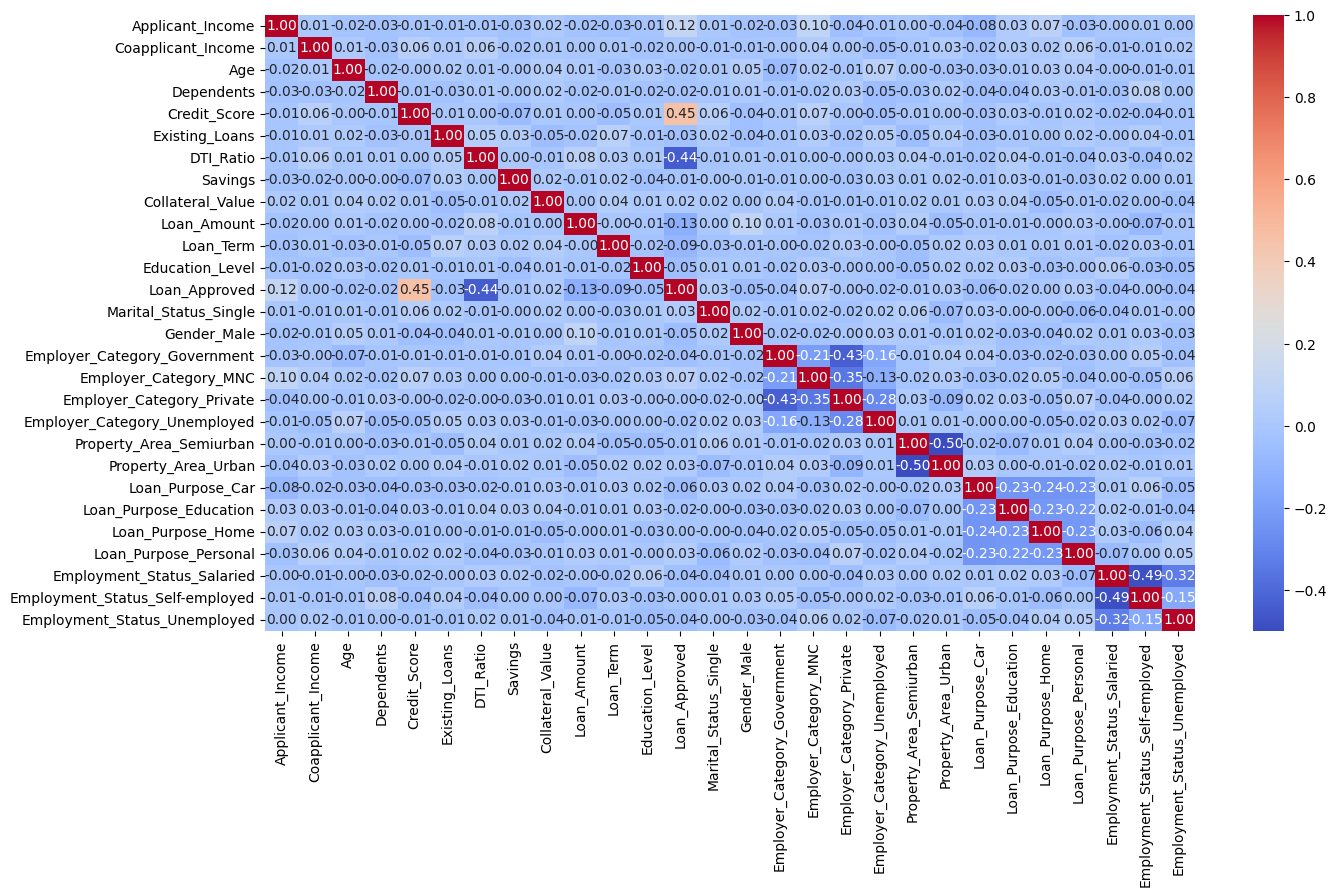

In [241]:
plt.figure(figsize=(15 , 8))
sns.heatmap(
    corr_matrix,
    annot= True ,
    fmt = ".2f",
    cmap = "coolwarm"
)

## 4. Splting and training

In [242]:
X = data.drop("Loan_Approved" , axis = 1)
Y = data["Loan_Approved"]

In [243]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [247]:
# Logistic  regression moddel

Logistic_model = LogisticRegression(max_iter=1000)
Logistic_model.fit(X_train_scaled , Y_train)

Y_predict = Logistic_model.predict(X_test_scaled)

# with the given problem statement we have to solve to major problem of false-positive and false-negative 
# precession_score - false positive
# recall_score - false negative

Precision = precision_score(Y_test , Y_predict)
Recall = recall_score(Y_test , Y_predict)
F1_score = f1_score(Y_test , Y_predict)

print(f"LOGISTIC REGRESSION evalution matrix")

print(f"Precision score : {Precision}")
print(f"Recall score : {Recall}")
print(f"F1_score : {F1_score}")

LOGISTIC REGRESSION evalution matrix
Precision score : 0.7833333333333333
Recall score : 0.7704918032786885
F1_score : 0.7768595041322314


In [248]:
# KNN moddel

KNN_model = KNeighborsClassifier()

param_grid = {"n_neighbors" : [5 , 9]}

classifierCV = GridSearchCV(
    KNN_model,
    param_grid,
    cv = 5,
    scoring = "recall"
)

classifierCV.fit(X_train , Y_train) # we apply it in the training data

y_predict = classifierCV.predict(X_test)

# with the given problem statement we have to solve to major problem of false-positive and false-negative 
# precession_score - false positive
# recall_score - false negative

Precision = precision_score(Y_test , Y_predict)
Recall = recall_score(Y_test , Y_predict)
F1_score = f1_score(Y_test , Y_predict)

print(f"KNN model ")

print(f"Precision score : {Precision}")
print(f"Recall score : {Recall}")
print(f"F1_score : {F1_score}")

KNN model 
Precision score : 0.7833333333333333
Recall score : 0.7704918032786885
F1_score : 0.7768595041322314


In [249]:
# Neive Bays  regression moddel

NeivBays_model = GaussianNB()
NeivBays_model.fit(X_train_scaled , Y_train)

Y_predict = NeivBays_model.predict(X_test_scaled)

# with the given problem statement we have to solve to major problem of false-positive and false-negative 
# precession_score - false positive
# recall_score - false negative

Precision = precision_score(Y_test , Y_predict)
Recall = recall_score(Y_test , Y_predict)
F1_score = f1_score(Y_test , Y_predict)

print(f"Naive Bayes Model")

print(f"Precision score : {Precision}")
print(f"Recall score : {Recall}")
print(f"F1_score : {F1_score}")

Naive Bayes Model
Precision score : 0.8035714285714286
Recall score : 0.7377049180327869
F1_score : 0.7692307692307693
